In [13]:
import discovery as ds
import jax
import discovery.samplers.numpyro as ds_numpyro
from matplotlib import pyplot as plt
import corner
import numpy as np

In [2]:
psr = ds.Pulsar.read_feather("sim3.feather")

In [3]:
signals = [
    psr.residuals,
    ds.makenoise_measurement_simple(psr),
    ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise'),
    ds.makegp_timing(psr),
]

In [4]:
psl = ds.PulsarLikelihood(signals)

In [5]:
p0 = ds.sample_uniform(psl.logL.params)
print(p0)

{'SIM3_efac': 1.2827244640748288, 'SIM3_log10_t2equad': -5.713152932782007, 'SIM3_rednoise_gamma': 0.9591095058683835, 'SIM3_rednoise_log10_A': -11.384839677172701}


In [6]:
psl.logL(p0), jax.grad(psl.logL)(p0)

(Array(24730.62125744, dtype=float64),
 {'SIM3_efac': Array(-1253.92429981, dtype=float64, weak_type=True),
  'SIM3_log10_t2equad': Array(-2666.81122497, dtype=float64, weak_type=True),
  'SIM3_rednoise_gamma': Array(4.46352071, dtype=float64, weak_type=True),
  'SIM3_rednoise_log10_A': Array(-130.06264876, dtype=float64, weak_type=True)})

In [7]:
npmodel = ds_numpyro.makemodel_transformed(psl.logL)
npsampler = ds_numpyro.makesampler_nuts(npmodel)

In [15]:
npsampler.run(jax.random.PRNGKey(np.random.randint(1)))

sample: 100%|██████████| 1536/1536 [04:42<00:00,  5.43it/s, 23 steps of size 7.82e-02. acc. prob=0.87]


In [12]:
chain = npsampler.to_df()

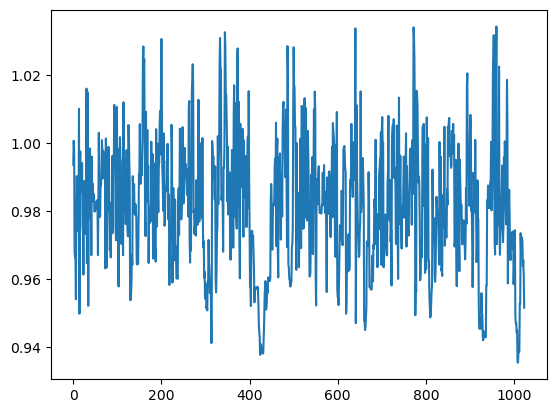

In [10]:
plt.plot(chain["SIM3_efac"].array)

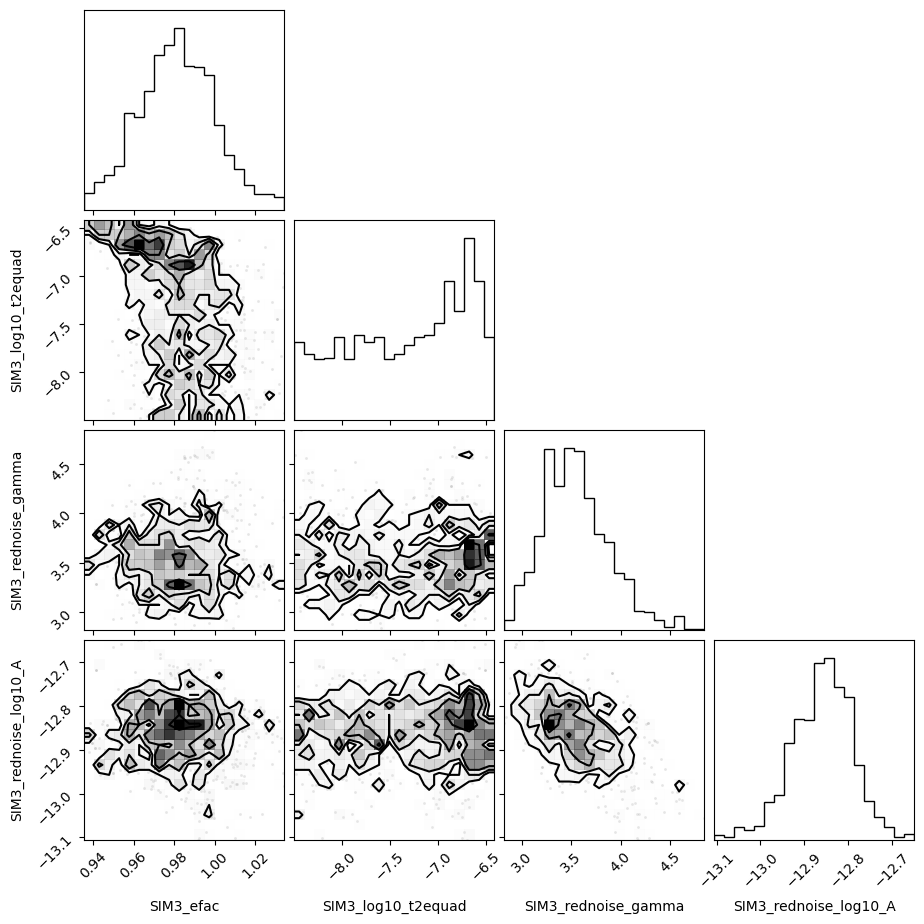

In [11]:
corner.corner(chain.to_numpy(), labels=psl.logL.params);